## IMPORTING LIBRARIES

In [1]:
#Imports pandas, numpy, matplotlib, seaborn and json,the 5 core libraries used throughout the notebook
#Pandas used for loading,cleaning and merging data
import pandas as pd #Loading CSV files, cleaning data, merging dataframes, groupby analysis
#Numpy Used for numerical operations
import numpy as np #Numerical operations and array handling in background calculations
#used for visualization
import matplotlib.pyplot as plt #Drawing all charts bar, horizontal bar, scatter, hexbin, histogram
#used for setting the global visual theme for all plots.
import seaborn as sns
#Used specifically to read the two .json files
import json #Reading newline delimited JSON files that pandas cannot load directly

## DATA LOADING

In [2]:
#Loads products.csv into a dataframe and prints its shape for a quick sanity check
products_csv=pd.read_csv("products.csv")
print(f"📦products_csv:{products_csv.shape}")
# .head() function used to view first 3 rows of the dataset
products_csv.head(3)

📦products_csv:(7982, 6)


,Uniq_id,SKU,Name,Description,Price,Av_Score
0,b6c0b6bea69c722939585baeac73c13d,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,2.625
1,93e5272c51d8cce02597e3ce67b7ad0a,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,3.000
2,013e320f2f2ec0cf5b3ff5418d688528,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,2.625


In [3]:
#Loads reviews.csv into a dataframe and prints shape 
reviews_csv=pd.read_csv("reviews.csv")
print(f"💌reviews_csv:{reviews_csv.shape}")
#.head() function used to view the first 3 rows of the dataset
reviews_csv.head(3)

💌reviews_csv:(39063, 4)


,Uniq_id,Username,Score,Review
0,b6c0b6bea69c722939585baeac73c13d,fsdv4141,2,You never have to worry about the fit...Alfred...
1,b6c0b6bea69c722939585baeac73c13d,krpz1113,1,Good quality fabric. Perfect fit. Washed very ...
2,b6c0b6bea69c722939585baeac73c13d,mbmg3241,2,I do not normally wear pants or capris that ha...


In [4]:
#Loads users.csv into a dataframe and prints shape 
users_csv=pd.read_csv("users.csv")
print(f"📚users_csv:{users_csv.shape}")
# .head() function used to view first 3 rows of the dataset
users_csv.head(3)

📚users_csv:(5000, 3)


,Username,DOB,State
0,bkpn1412,31.07.1983,Oregon
1,gqjs4414,27.07.1998,Massachusetts
2,eehe1434,08.08.1950,Idaho


In [5]:
#Reads jcpenney_products.json line by line (newline-delimited JSON) and converts to a dataframe
with open("jcpenney_products.json","r") as f:
    products_json=pd.DataFrame([json.loads(line) for line in f])
    print(f"📦products_json:{products_json.shape}")
# .head() function used to view first 3 rows of the dataset
products_json.head(3)

📦products_json:(7982, 15)


,uniq_id,sku,name_title,description,list_price,sale_price,category,category_tree,average_product_rating,product_url,product_image_urls,brand,total_number_reviews,Reviews,Bought With
0,b6c0b6bea69c722939585baeac73c13d,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16,alfred dunner,jcpenney|women|alfred dunner,2.625,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'fsdv4141', 'Review': 'You never hav...","[898e42fe937a33e8ce5e900ca7a4d924, 8c02c262567..."
1,93e5272c51d8cce02597e3ce67b7ad0a,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16,alfred dunner,jcpenney|women|alfred dunner,3.000,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'tpcu2211', 'Review': 'You never hav...","[bc9ab3406dcaa84a123b9da862e6367d, 18eb69e8fc2..."
2,013e320f2f2ec0cf5b3ff5418d688528,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16,view all,jcpenney|women|view all,2.625,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'pcfg3234', 'Review': 'You never hav...","[3ce70f519a9cfdd85cdbdecd358e5347, b0295c96d2b..."


In [6]:
#Reads jcpenney_reviewers.json line by line and converts to a dataframe
with open("jcpenney_reviewers.json","r") as f:
    reviewers_json=pd.DataFrame([json.loads(line) for line in f])
    print(f"💻reviewers_json:{reviewers_json.shape}")
# .head() function used to view first 3 rows of the dataset
reviewers_json.head(3)


💻reviewers_json:(5000, 4)


,Username,DOB,State,Reviewed
0,bkpn1412,31.07.1983,Oregon,[cea76118f6a9110a893de2b7654319c0]
1,gqjs4414,27.07.1998,Massachusetts,[fa04fe6c0dd5189f54fe600838da43d3]
2,eehe1434,08.08.1950,Idaho,[]


## DATA CLEANING

In [7]:
#Cleans products_csv: lowercases columns, removes duplicates by uniq_id, converts price and av_score to numeric, drops nulls
products_csv.columns=products_csv.columns.str.strip().str.lower()
#drop.duplicate drop the duplicate value
products_csv.drop_duplicates(subset="uniq_id",inplace=True)
#pd.to_numeric convert all the values to numeric format
products_csv["price"]=pd.to_numeric(products_csv["price"],errors="coerce")
products_csv["av_score"]=pd.to_numeric(products_csv["av_score"],errors="coerce")
#pd.dropna drops the null value
products_csv.dropna(subset=["uniq_id", "price"], inplace=True)
products_csv.head(3)

,uniq_id,sku,name,description,price,av_score
0,b6c0b6bea69c722939585baeac73c13d,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,2.625
1,93e5272c51d8cce02597e3ce67b7ad0a,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,3.000
2,013e320f2f2ec0cf5b3ff5418d688528,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,2.625


In [8]:
#Cleans reviews_csv: lowercases columns, removes duplicate rows, converts score to numeric, drops null scores
reviews_csv.columns=reviews_csv.columns.str.strip().str.lower()
reviews_csv.drop_duplicates(inplace=True)
reviews_csv["score"]=pd.to_numeric(reviews_csv["score"],errors="coerce")
reviews_csv.dropna(subset=["uniq_id","score"],inplace=True)
reviews_csv.head(3)

,uniq_id,username,score,review
0,b6c0b6bea69c722939585baeac73c13d,fsdv4141,2,You never have to worry about the fit...Alfred...
1,b6c0b6bea69c722939585baeac73c13d,krpz1113,1,Good quality fabric. Perfect fit. Washed very ...
2,b6c0b6bea69c722939585baeac73c13d,mbmg3241,2,I do not normally wear pants or capris that ha...


In [9]:
#Cleans users_csv: lowercases columns, removes duplicates, parses DOB as datetime, calculates age in years
users_csv.columns=users_csv.columns.str.strip().str.lower()
users_csv.drop_duplicates(subset="username",inplace=True)
users_csv["dob"]=pd.to_datetime(users_csv["dob"],format="%d.%m.%Y",errors="coerce")
users_csv["age"]=(pd.Timestamp("2024-01-01")-users_csv["dob"]).dt.days//365
users_csv.head(3)

,username,dob,state,age
0,bkpn1412,1983-07-31,Oregon,40
1,gqjs4414,1998-07-27,Massachusetts,25
2,eehe1434,1950-08-08,Idaho,73


In [10]:
#Cleans products_json: lowercases columns, removes duplicates, converts list_price and sale_price to numeric
products_json.columns=products_json.columns.str.strip().str.lower()
products_json.drop_duplicates(subset="uniq_id",inplace=True)
products_json["list_price"]=pd.to_numeric(products_json["list_price"],errors="coerce")
products_json["sale_price"]=pd.to_numeric(products_json["sale_price"],errors="coerce")
products_json.head(3)

,uniq_id,sku,name_title,description,list_price,sale_price,category,category_tree,average_product_rating,product_url,product_image_urls,brand,total_number_reviews,reviews,bought with
0,b6c0b6bea69c722939585baeac73c13d,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16,alfred dunner,jcpenney|women|alfred dunner,2.625,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'fsdv4141', 'Review': 'You never hav...","[898e42fe937a33e8ce5e900ca7a4d924, 8c02c262567..."
1,93e5272c51d8cce02597e3ce67b7ad0a,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16,alfred dunner,jcpenney|women|alfred dunner,3.000,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'tpcu2211', 'Review': 'You never hav...","[bc9ab3406dcaa84a123b9da862e6367d, 18eb69e8fc2..."
2,013e320f2f2ec0cf5b3ff5418d688528,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16,view all,jcpenney|women|view all,2.625,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'pcfg3234', 'Review': 'You never hav...","[3ce70f519a9cfdd85cdbdecd358e5347, b0295c96d2b..."


In [11]:
#Cleans reviewers_json: lowercases columns, removes duplicates, parses DOB, calculates age
reviewers_json.columns=reviewers_json.columns.str.strip().str.lower()
reviewers_json.drop_duplicates(subset="username", inplace=True)
reviewers_json["dob"]=pd.to_datetime(reviewers_json["dob"], format="%d.%m.%Y", errors="coerce")
reviewers_json["age"]=(pd.Timestamp("2024-01-01") - reviewers_json["dob"]).dt.days // 365
reviewers_json.head(3)


,username,dob,state,reviewed,age
0,bkpn1412,1983-07-31,Oregon,[cea76118f6a9110a893de2b7654319c0],40
1,gqjs4414,1998-07-27,Massachusetts,[fa04fe6c0dd5189f54fe600838da43d3],25
2,eehe1434,1950-08-08,Idaho,[],73


## DATA MERGING

In [12]:
#Merges reviews with product info (name, price, av_score) from products_csv on uniq_id using left join
df=reviews_csv.merge(products_csv[["uniq_id", "name", "price", "av_score"]],on="uniq_id", how="left")

In [13]:
#Merges the result with user demographics (state, age) from users_csv on username using left join
df=df.merge(users_csv[["username","state","age"]],on="username",how="left")

In [14]:
#Merges with products_json to bring in category, brand and sale_price.creates the final master dataframe
df=df.merge(products_json[["uniq_id", "category", "brand", "sale_price"]].drop_duplicates("uniq_id"),on="uniq_id", how="left")

In [15]:
#Prints final dataframe shape and previews first 3 rows to confirm the merge is correct
print(f"Final merged dataframe shape:{df.shape}")
# .head(3) function used to view first 3 rows of the dataset
print(df.head(3))

Final merged dataframe shape:(39063, 12)
                            uniq_id  username  score  \
0  b6c0b6bea69c722939585baeac73c13d  fsdv4141      2   
1  b6c0b6bea69c722939585baeac73c13d  krpz1113      1   
2  b6c0b6bea69c722939585baeac73c13d  mbmg3241      2   

                                              review  \
0  You never have to worry about the fit...Alfred...   
1  Good quality fabric. Perfect fit. Washed very ...   
2  I do not normally wear pants or capris that ha...   

                                          name  price  av_score  \
0  Alfred Dunner® Essential Pull On Capri Pant  41.09     2.625   
1  Alfred Dunner® Essential Pull On Capri Pant  41.09     2.625   
2  Alfred Dunner® Essential Pull On Capri Pant  41.09     2.625   

                      state  age       category          brand  sale_price  
0            American Samoa   43  alfred dunner  Alfred Dunner       24.16  
1                  Virginia   36  alfred dunner  Alfred Dunner       24.16  
2  Northe

## DATA ANALYSIS AND VISUALAIZATION

## Distribution of Review Scores

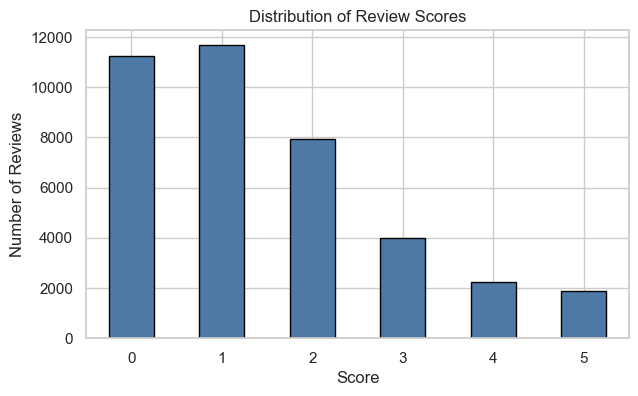

In [16]:
#Bar chart showing distribution of review scores (0-5), identifies which scores are most common across all reviews
#Set white background with grid lines
sns.set_theme(style="whitegrid")
#Create a figure of width 7 and height 4 inches
plt.figure(figsize=(7,4))
#value_counts() give Count how many times each score appears
#sort_index() Sort scores in ascending order
#.plot(kind="bar",color="#4E79A7",edgecolor="black")Plot as a bar chart,Fill bars with steel blue color,Add black border around each bar
df["score"].value_counts().sort_index().plot(kind="bar",color="#4E79A7",edgecolor="black")
plt.title("Distribution of Review Scores")
plt.xlabel("Score")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

## Top 10 Brands by Average Rating

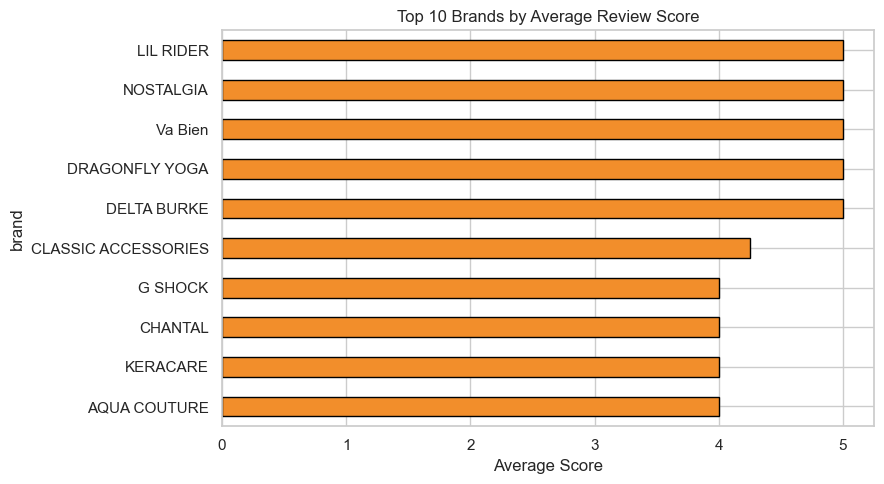

In [17]:
#Horizontal bar chart of top 10 brands ranked by average review score — shows which brands customers rate highest
#groupby()and mean() Group by brand and calculate average score for each
#sort_values Sort brands from highest to lowest average score
#head(10) Keep only the top 10 highest rated brands
brand_rating=df.groupby("brand")["score"].mean().sort_values(ascending=False).head(10)
#Create a figure of width 9 and height 5 inches
plt.figure(figsize=(9,5))
brand_rating.sort_values().plot(kind="barh", color="#F28E2B",edgecolor="black")
plt.title("Top 10 Brands by Average Review Score")
plt.xlabel("Average Score")
plt.tight_layout()
plt.show()

## Top 10 Categories by Review Count

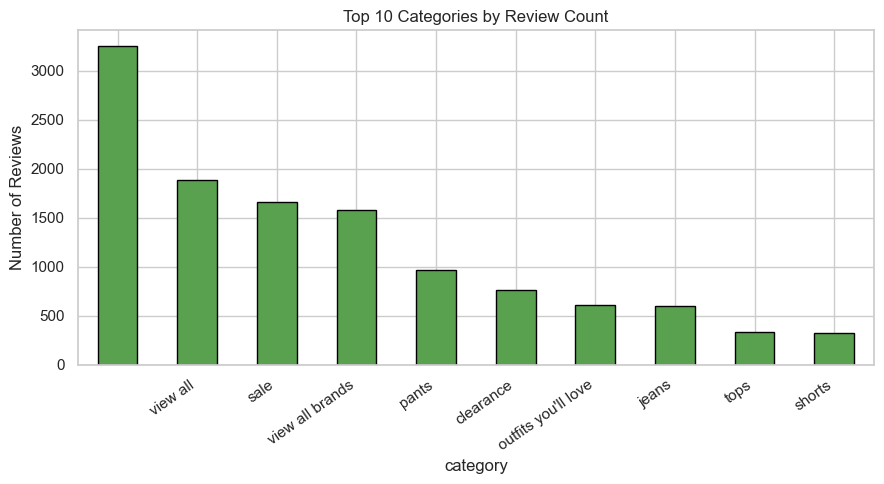

In [18]:
#bar chart of top 10 product categories by review count,shows which categories have the highest customer activity
categories_counts = df["category"].value_counts().head(10)
plt.figure(figsize=(9,5))
categories_counts.plot(kind="bar",color="#59A14F",edgecolor="black")
plt.title("Top 10 Categories by Review Count")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=35,ha="right")
plt.tight_layout()
plt.show()

## Price vs Average Rating (scatter)

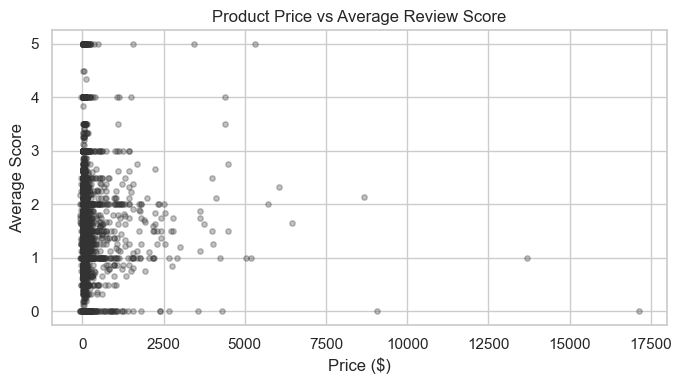

In [19]:
#Hexbin density plot of product price vs average score,reveals how price relates to customer satisfaction
product_stats = df.groupby("uniq_id").agg(avg_score=("score","mean"),price=("price","first")).dropna()
plt.figure(figsize=(7,4))
plt.scatter(product_stats["price"], product_stats["avg_score"],alpha=0.3,s=15,color="#333333")
plt.title("Product Price vs Average Review Score")
plt.xlabel("Price ($)")
plt.ylabel("Average Score")
plt.tight_layout()
plt.show()

## Top 15 States by Review Count

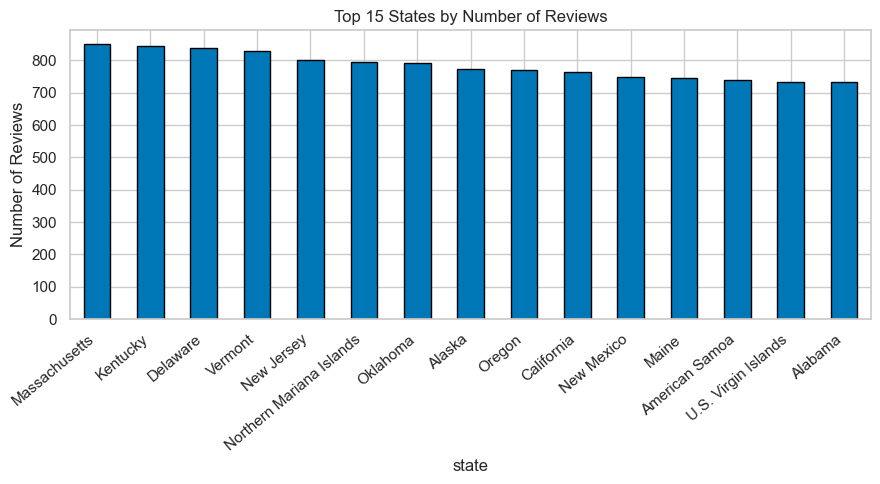

In [20]:
#Bar chart of top 15 US states by review count,shows regional distribution of customer engagement
state_counts=df["state"].value_counts().head(15)
plt.figure(figsize=(9,5))
state_counts.plot(kind="bar", color="#0077B6", edgecolor="black")
plt.title("Top 15 States by Number of Reviews")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()

## Average Score by Age Group

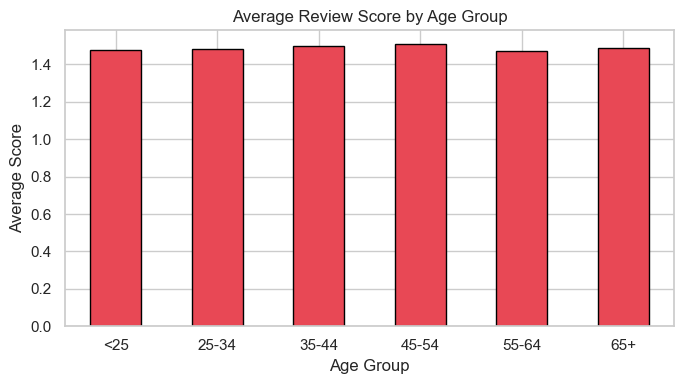

In [21]:
#Bar chart of average review score by age group,compares satisfaction levels across customer demographics
df["age_group"]=pd.cut(df["age"], bins=[0, 25, 35, 45, 55, 65, 100],labels=["<25", "25-34", "35-44", "45-54", "55-64", "65+"])
age_score=df.groupby("age_group", observed=True)["score"].mean()
plt.figure(figsize=(7,4))
age_score.plot(kind="bar",color="#E84855",edgecolor="black")
plt.title("Average Review Score by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Discount % Distribution

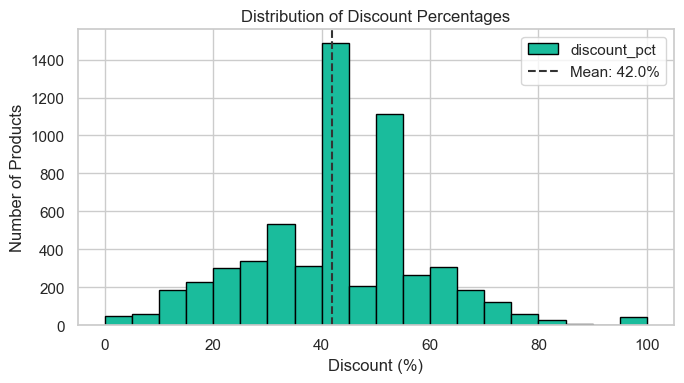

In [46]:
#Histogram showing distribution of discount percentages with mean line,reveals JCPenney pricing and markdown strategy
products_json["discount_pct"] = ((products_json["list_price"] - products_json["sale_price"]) / products_json["list_price"] * 100).clip(0, 100)
plt.figure(figsize=(7, 4))
products_json["discount_pct"].dropna().plot(kind="hist", bins=20, color="#1ABC9C", edgecolor="black")
plt.axvline(products_json["discount_pct"].mean(), color="#333333", linestyle="--",label=f"Mean: {products_json['discount_pct'].mean():.1f}%")
plt.title("Distribution of Discount Percentages")
plt.xlabel("Discount (%)")
plt.ylabel("Number of Products")
plt.legend()
plt.tight_layout()
plt.show()

## Importing libraries for building model

In [29]:
#A Decision Tree learns by splitting data into branches based on feature conditions
from sklearn.tree import DecisionTreeClassifier
#It divides your dataset into two parts.
#Training set = the data the model learns from
#Testing set = unseen data used to evaluate how well the model generalised
from sklearn.model_selection import train_test_split
#classification_report, confusion_matrix.These are your evaluation tools.
from sklearn.metrics import classification_report, confusion_matrix

## Data Modelling


In [30]:
#Calculates how much discount (%) is applied to each product
products_json["discount_pct"] = ((products_json["list_price"] - products_json["sale_price"])/ products_json["list_price"] * 100).clip(0, 100)
#Joins review data with product details (name, price, average score)
#how="left" keeps all reviews even if no matching product is found
df = reviews_csv.merge(products_csv[["uniq_id", "name", "price", "av_score"]], on="uniq_id", how="left")
#Adds user demographics (state, age) to each review
df = df.merge(users_csv[["username", "state", "age"]], on="username", how="left")
#Add Product JSON Details
df = df.merge(products_json[["uniq_id", "category", "brand", "sale_price", "discount_pct"]].drop_duplicates("uniq_id"),on="uniq_id", how="left")

In [31]:
#.apply(lambda x: ...)= applies a function to every row in that column
#label creation
df["review_label"] = df["score"].apply(lambda x: "Positive" if x >= 3 else "Negative")

In [32]:
#From our large merged dataframe, we are picking only the 4 columns that required for the model.
model_df = df[["price", "age", "discount_pct", "review_label"]].dropna()

In [33]:
#X contains the independent variables which the information the model uses to learn
#X=feature input
X = model_df[["price", "age", "discount_pct"]]
#`y` contains the dependent variable which the answer the model is trying to predict
y = model_df["review_label"]

In [34]:
#This is the train/test split. we dividing our data into two sets so the model learns on one and is evaluated on the other
# test_size=0.2 is which split the data 80% for trainind and remaining 20% for testing
# random_state=42 is randomly shuffles your data before splitting. it can be any number.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
#This is the model building and training phase
#we are creating a Decision Tree model with two specific settings
#max_depth=3 will controls how far the tree can grow
# random_state=42 ensures the tree builds the same way every run
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [51]:
#testing how well our trained model performs on unseen data.
y_pred=model.predict(X_test)
#calculating accuracy
accuracy=(y_pred == y_test).mean()*100
#confusion matrix Produces a grid showing exactly where the model was right and wrong
cm= confusion_matrix(y_test, y_pred, labels=["Positive","Negative"])
#classification report
#Generates a full performance breakdown for each class.
report=classification_report(y_test, y_pred, output_dict=True,zero_division=0)

## Classification report

In [53]:
#Displaying result
print(f"Model Accuracy:{accuracy:.1f}%")
print(classification_report(y_test,y_pred,zero_division=0))
#Precision=Of all predicted Positives, how many were actually Positive [TP/(TP+FP)]
#Recall=Of all actual Positives, how many did the model catch [TP/(TP+FN)]
#F1-Score=Balance between Precision and Recall [2×(P×R)/(P+R)]
#Accuracy=Overall correct predictions [(TP+TN)/Total]

Model Accuracy:78.4%
              precision    recall  f1-score   support

    Negative       0.78      1.00      0.88      4211
    Positive       0.00      0.00      0.00      1159

    accuracy                           0.78      5370
   macro avg       0.39      0.50      0.44      5370
weighted avg       0.61      0.78      0.69      5370



## Feature importance visualisation

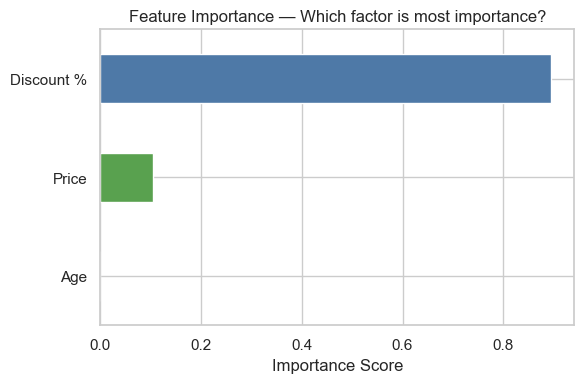

In [54]:
#sort_values() Sorts from least to most important
#(model.feature_importances) Extracts importance scores from the trained Decision Tree
importances = pd.Series(model.feature_importances_,index=["Price", "Age", "Discount %"]).sort_values()
#Creates a blank canvas for the chart
#figsize=(6, 4) sets the size= 6 inches wide, 4 inches tall
plt.figure(figsize=(6, 4))
importances.plot(kind="barh", color=["#F28E2B", "#59A14F", "#4E79A7"], edgecolor="white")
#plt.title adds a descriptive heading to the chart
plt.title("Feature Importance — Which factor is most importance?")
#plt.xlabel() Labels the x-axis so viewers know what the numbers mean
plt.xlabel("Importance Score")
#plt.tight_layout() Auto adjusts spacing so nothing gets cut off
plt.tight_layout()
#plt.show() display outpout
plt.show()

## Confusion Matrix

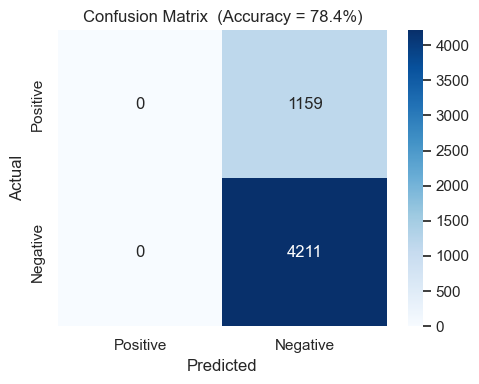

In [55]:
plt.figure(figsize=(5, 4))
#Drawing the Heatmap
#annot=true prints the actual number inside each cell
#fmd="d" show the whole number
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",xticklabels=["Positive", "Negative"],yticklabels=["Positive", "Negative"])
plt.title(f"Confusion Matrix  (Accuracy = {accuracy:.1f}%)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## Actual vs Predicted counts
## Counting Actual and Predicted Labels

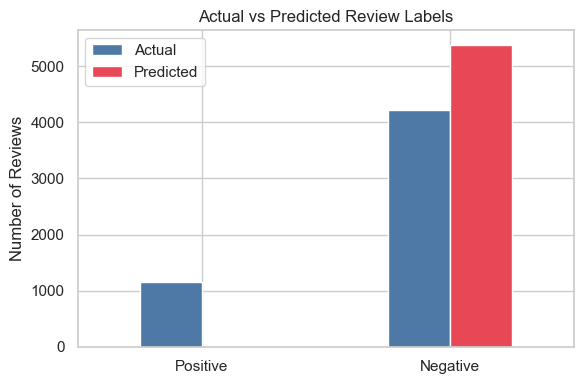

In [56]:
#y_test.value_counts()counts how many real Positives and Negatives exist in test data
#pd.Series(y_pred).value_counts()Converts predictions array to Series, then counts each label
actual_counts  = y_test.value_counts()
predict_counts = pd.Series(y_pred).value_counts()
#.get("Positive", 0) means give me the count for "Positive" and return 0 if its doesn't exist. same for .get("Negative",0)
compare_df = pd.DataFrame({"Actual":[actual_counts.get("Positive",0),actual_counts.get("Negative", 0)],"Predicted": [predict_counts.get("Positive", 0), predict_counts.get("Negative", 0)]
},index=["Positive", "Negative"])
plt.figure(figsize=(6, 4))
compare_df.plot(kind="bar", color=["#4E79A7", "#E84855"], edgecolor="white", ax=plt.gca())
plt.title("Actual vs Predicted Review Labels")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

**REFERENCE**
* McKinney, W. (2022) Python for data analysis: data wrangling with pandas, NumPy and Jupyter. 3rd edn. Sebastopol: O'Reilly Media.
* Hunter, J.D. (2007) 'Matplotlib: a 2D graphics environment', Computing in Science & Engineering, 9(3), pp. 90–95.
* Waskom, M. (2021) 'Seaborn: statistical data visualization', Journal of Open Source Software, 6(60), p. 3021.
* Breiman, L., Friedman, J., Olshen, R. and Stone, C. (1984) Classification and regression trees. New York: Chapman & Hall/CRC.

